## 2. Autovit - Price Prediction
### 1.1 Setup

In [112]:
# Import necessary libraries
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.linear_model import LinearRegression, QuantileRegressor, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer, mean_pinball_loss
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from scipy.stats import loguniform, uniform, randint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re

pd.set_option('future.no_silent_downcasting', True)

In [113]:
# Load the dataset
train_data = pd.read_csv('autovit/train_cars_listings.csv', low_memory=False)
test_data = pd.read_csv('autovit/val_cars_listings.csv', low_memory=False)

### 1.2 Data Exploration

In [114]:
train_data.info()
train_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18988 entries, 0 to 18987
Data columns (total 37 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   nume                                 18988 non-null  object 
 1   pret                                 18988 non-null  float64
 2   Oferit de                            18988 non-null  object 
 3   Are VIN (Serie sasiu)                10877 non-null  object 
 4   Marca                                18988 non-null  object 
 5   Model                                18988 non-null  object 
 6   Versiune                             14946 non-null  object 
 7   Anul fabricației                     18988 non-null  int64  
 8   Km                                   18945 non-null  float64
 9   Combustibil                          18988 non-null  object 
 10  Putere                               18983 non-null  float64
 11  Capacitate cilindrica       

,nume,pret,Oferit de,Are VIN (Serie sasiu),Marca,Model,Versiune,Anul fabricației,Km,Combustibil,...,Electronice si sisteme de asistenta,Siguranta,Norma de poluare,Tara de origine,Data primei inmatriculari,Garantie de la producator pana la,Vehicule electrice,Tuning,Autonomie,Capacitate baterie
0,Opel Astra,3150.0,Firma,NaN,Opel,Astra,NaN,2002,160000.0,Benzina,...,"['Pilot automat', 'Oglinzi exterioare cu regla...","['ABS', 'ESP', 'Airbag sofer', 'Airbag scaun p...",Euro 4,Germania,2002-12-15,NaN,NaN,NaN,NaN,NaN
1,Renault Megane,12495.0,Firma,NaN,Renault,Megane,NaN,2017,159242.0,Diesel,...,"['Pilot automat', 'Senzori parcare fata', 'Sen...","['ABS', 'ESP', 'EBD', 'Franare asistata', 'Sis...",Euro 6,Germania,2017-11-06,NaN,NaN,NaN,NaN,NaN
2,BMW X4 xDrive20d Aut. M Sport,24990.0,Firma,Da,BMW,X4,xDrive20d Aut. M Sport,2016,145000.0,Diesel,...,"['Pilot automat', 'Faruri LED', 'Senzori parca...","['ABS', 'ESP', 'Sistem pre-coliziune lateral',...",Euro 6,NaN,NaN,NaN,['Sistem recuperare energie'],NaN,NaN,NaN
3,Volkswagen Passat 2.0 TDI DSG Highline,22850.0,Firma,Da,Volkswagen,Passat,2.0 TDI DSG Highline,2019,77874.0,Diesel,...,"['Pilot automat adaptiv (distronic)', 'Faruri ...","['ABS', 'ESP', 'Franare asistata', 'Sistem asi...",Euro 6,Romania,2019-12-06,NaN,['Sistem recuperare energie'],NaN,NaN,NaN
4,Volkswagen Golf,7199.0,Firma,Da,Volkswagen,Golf,NaN,2010,230000.0,Benzina,...,"['Pilot automat', 'Servodirectie']","['ABS', 'ESP']",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [115]:
train_data.describe()

,pret,Anul fabricației,Km,Putere,Capacitate cilindrica,Consum Extraurban,Consum Urban,Emisii CO2,Numar de portiere,Numar locuri
count,18988.000000,18988.000000,1.894500e+04,18983.000000,18447.000000,8352.000000,13064.000000,9635.000000,18759.000000,14757.000000
mean,25424.654675,2016.609490,1.381373e+05,179.185587,1977.705210,4.879095,6.752013,155.590939,4.707021,5.000745
std,29824.752654,4.780368,9.048320e+04,93.524671,659.091494,1.173531,2.260320,1753.493092,0.625786,0.676494
min,600.000000,1969.000000,1.000000e+00,3.000000,479.000000,2.900000,2.200000,2.000000,2.000000,1.000000
25%,9490.000000,2014.000000,6.543000e+04,116.000000,1560.000000,4.100000,5.300000,113.000000,5.000000,5.000000
50%,16500.000000,2018.000000,1.400000e+05,150.000000,1968.000000,4.700000,6.300000,132.000000,5.000000,5.000000
75%,29999.000000,2020.000000,2.030000e+05,200.000000,1998.000000,5.400000,7.700000,156.000000,5.000000,5.000000
max,666666.000000,2024.000000,2.080288e+06,1020.000000,6750.000000,12.900000,75.000000,172139.000000,6.000000,9.000000


In [116]:
train_data.isnull().sum()

nume                                       0
pret                                       0
Oferit de                                  0
Are VIN (Serie sasiu)                   8111
Marca                                      0
Model                                      0
Versiune                                4042
Anul fabricației                           0
Km                                        43
Combustibil                                0
Putere                                     5
Capacitate cilindrica                    541
Transmisie                              2116
Consum Extraurban                      10636
Cutie de viteze                            1
Consum Urban                            5924
Tip Caroserie                              0
Emisii CO2                              9353
Numar de portiere                        229
Culoare                                    0
Numar locuri                            4231
Garantie dealer (inclusa in pret)      13741
Primul pro

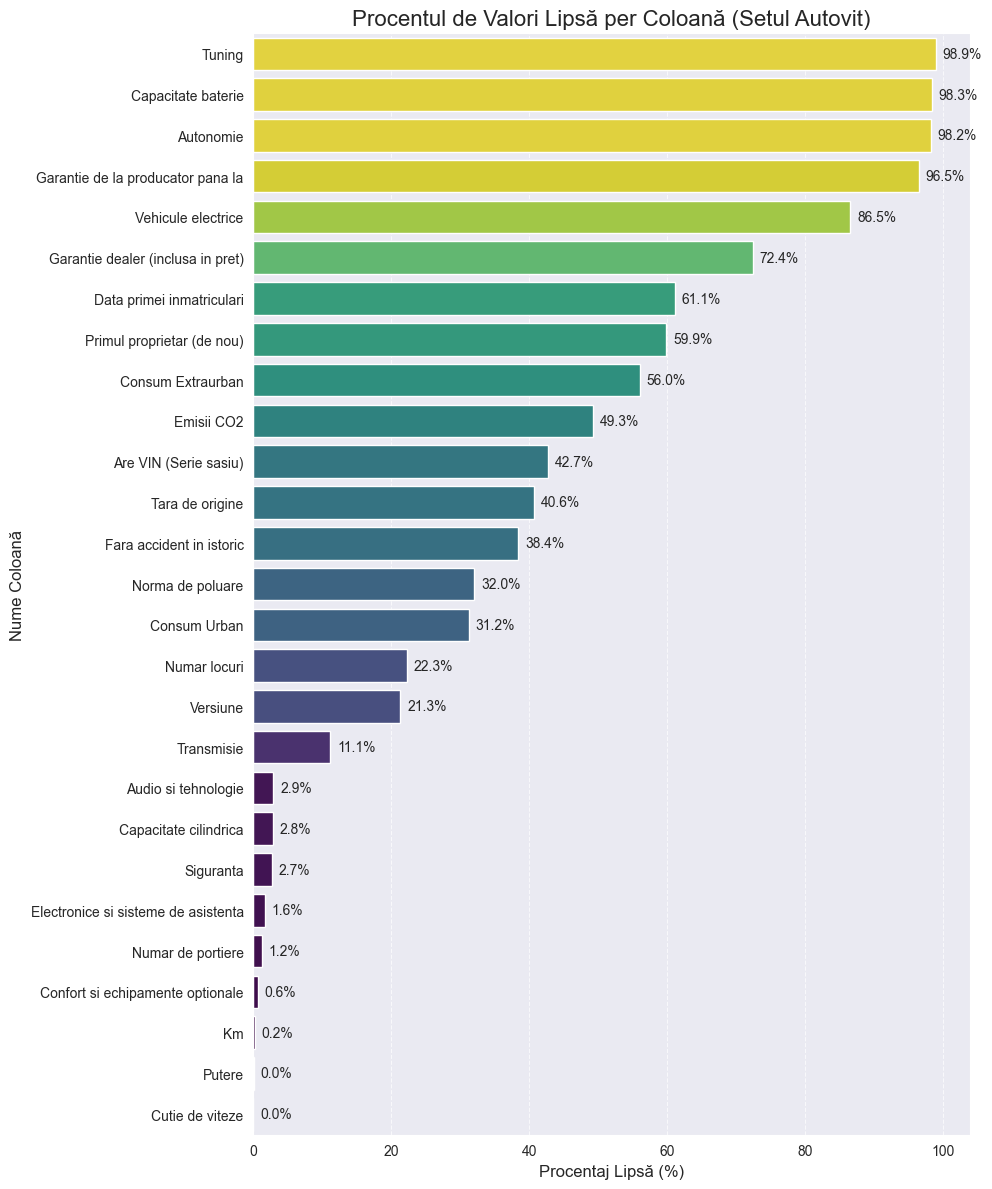

In [117]:
def plot_missing_data(train_data: pd.DataFrame):
    missing_percentages = train_data.isnull().sum() / len(train_data) * 100
    missing_percentages = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

    plt.figure(figsize=(10, 12))
    sns.barplot(x=missing_percentages.values, y=missing_percentages.index, palette="viridis", hue=missing_percentages.values, legend=False)

    plt.title('Procentul de Valori Lipsă per Coloană (Setul Autovit)', fontsize=16)
    plt.xlabel('Procentaj Lipsă (%)', fontsize=12)
    plt.ylabel('Nume Coloană', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    # Adăugăm procentele la capătul barelor pentru claritate
    for index, value in enumerate(missing_percentages.values):
        plt.text(value + 1, index, f'{value:.1f}%', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

plot_missing_data(train_data)

In [118]:
bool_patterns = ['yes', 'no', 'true', 'false', '1', '0', 'y', 'n', 'da', 'nu', 'nan', 'none', 'null']
binary_cols =[]
one_hot_cols = []

object_cols = train_data.select_dtypes(include=['object']).columns

print('Potential object columns to convert to boolean:')
for col in object_cols:
    unique_vals_non_null = train_data[col].unique()
    if len(unique_vals_non_null) == 0:
        continue
    elif len(unique_vals_non_null) == 2:
        unique_set = set(map(str.lower, map(str, unique_vals_non_null)))
        if unique_set.issubset(set(bool_patterns)):
            binary_cols.append(col)
            print(f"- '{col}'")

print('\nPotential object columns to apply one-hot encoding:')
too_many_unique_vals = []
for col in object_cols:
    unique_vals_non_null = train_data[col].dropna().unique()
    if len(unique_vals_non_null) > 0: # Avoid list columns
        if '[' in str(unique_vals_non_null[0]) and ']' in str(unique_vals_non_null[0]):
            continue

    if len(unique_vals_non_null) <= 15 and col not in binary_cols:
        one_hot_cols.append(col)
        print(f"- '{col}' with {len(unique_vals_non_null)} unique values: {unique_vals_non_null}")
    else:
        too_many_unique_vals.append((col, len(unique_vals_non_null)))

print('\nColumns with too many unique values to one-hot encode:')
for col, count in too_many_unique_vals:
    if col not in binary_cols:
        print(f"- '{col}' with {count} unique values")

Potential object columns to convert to boolean:
- 'Are VIN (Serie sasiu)'
- 'Primul proprietar (de nou)'
- 'Fara accident in istoric'
- 'Tuning'

Potential object columns to apply one-hot encoding:
- 'Oferit de' with 2 unique values: ['Firma' 'Privat']
- 'Combustibil' with 8 unique values: ['Benzina' 'Diesel' 'Hibrid' 'Plug-In Hybrid' 'Electric' 'Benzina + GPL'
 'Benzina + CNG' 'Hibrid Plug-In']
- 'Transmisie' with 4 unique values: ['Fata' '4x4 (automat)' '4x4 (manual)' 'Spate']
- 'Cutie de viteze' with 2 unique values: ['Automata' 'Manuala']
- 'Tip Caroserie' with 9 unique values: ['Compacta' 'Combi' 'SUV' 'Sedan' 'Coupe' 'Masina de oras' 'Monovolum'
 'Masina mica' 'Cabrio']
- 'Culoare' with 12 unique values: ['Argint' 'Albastru' 'Negru' 'Gri' 'Alb' 'Bej' 'Rosu' 'Maro' 'Verde'
 'Alte culori' 'Portocaliu' 'Galben/Auriu']
- 'Stare' with 2 unique values: ['Second hand' 'Nou']
- 'Norma de poluare' with 13 unique values: ['Euro 4' 'Euro 6' 'Euro 5' 'Euro 6d-Temp' 'Euro 6d' 'Euro 6b' 'Euro 

In [119]:
# Converting identified binary columns from object to numerical format
map_to_binary = {
    'Da': 1, 'da': 1, 'True': 1, 'true': 1, '1': 1, 1: 1,
    'Nu': 0, 'nu': 0, 'False': 0, 'false': 0, '0': 0, 0: 0,
    'nan':0, 'None':0, 'none':0, 'null':0, 'Null':0, np.nan:0
}

for col in binary_cols:
    train_data[col] = train_data[col].replace(map_to_binary).astype('bool')
    test_data[col] = test_data[col].replace(map_to_binary).astype('bool')

print(train_data[binary_cols].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18988 entries, 0 to 18987
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Are VIN (Serie sasiu)       18988 non-null  bool 
 1   Primul proprietar (de nou)  18988 non-null  bool 
 2   Fara accident in istoric    18988 non-null  bool 
 3   Tuning                      18988 non-null  bool 
dtypes: bool(4)
memory usage: 74.3 KB
None


In [120]:
# Transform 'Autonomie' and 'Capacitate baterie' to int for initial exploration
def extract_number(text_value):
    if pd.isna(text_value):
        return None

    match = re.search(r'[\d\.]+', str(text_value))
    if match:
        try:
            return float(match.group(0))
        except ValueError:
            return None
    return None

train_data['Autonomie'] = train_data['Autonomie'].apply(extract_number).astype('float')
test_data['Autonomie'] = test_data['Autonomie'].apply(extract_number).astype('float')

train_data['Capacitate baterie'] = train_data['Capacitate baterie'].apply(extract_number).astype('float')
test_data['Capacitate baterie'] = test_data['Capacitate baterie'].apply(extract_number).astype('float')

train_data['Garantie dealer (inclusa in pret)'] = train_data['Garantie dealer (inclusa in pret)'].apply(extract_number).astype('float')
test_data['Garantie dealer (inclusa in pret)'] = test_data['Garantie dealer (inclusa in pret)'].apply(extract_number).astype('float')

In [121]:
# One-hot encoding for identified categorical columns
train_data = pd.get_dummies(train_data, columns=one_hot_cols, drop_first=True)
test_data = pd.get_dummies(test_data, columns=one_hot_cols, drop_first=True)
test_data = test_data.reindex(columns=train_data.columns, fill_value=0)

train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18988 entries, 0 to 18987
Data columns (total 73 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   nume                                 18988 non-null  object 
 1   pret                                 18988 non-null  float64
 2   Are VIN (Serie sasiu)                18988 non-null  bool   
 3   Marca                                18988 non-null  object 
 4   Model                                18988 non-null  object 
 5   Versiune                             14946 non-null  object 
 6   Anul fabricației                     18988 non-null  int64  
 7   Km                                   18945 non-null  float64
 8   Putere                               18983 non-null  float64
 9   Capacitate cilindrica                18447 non-null  float64
 10  Consum Extraurban                    8352 non-null   float64
 11  Consum Urban                

Am găsit 277 mașini unde AMBELE valori (curățate) sunt prezente.


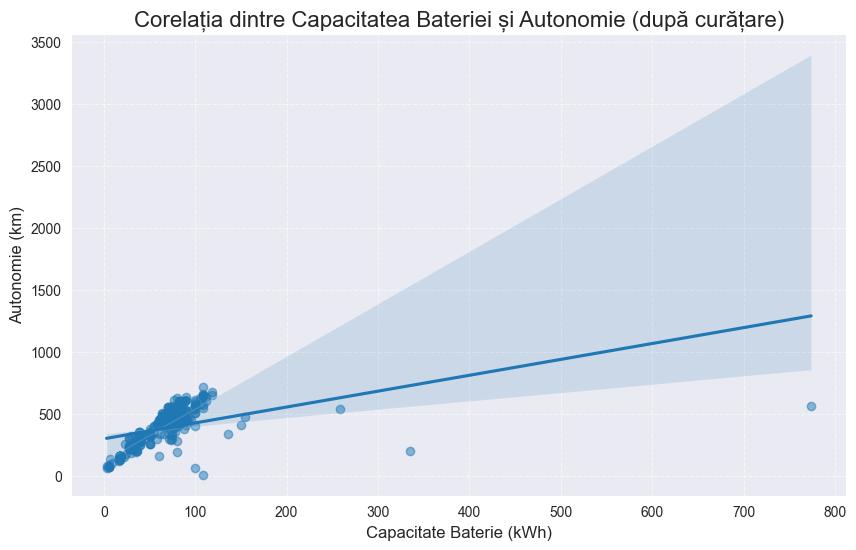


Coeficientul de corelație Pearson este: 0.47


In [122]:
ev_data = train_data[['Capacitate baterie', 'Autonomie']].copy()

def extract_number(text_value):
    if pd.isna(text_value):
        return None

    match = re.search(r'[\d\.]+', str(text_value))
    if match:
        try:
            return float(match.group(0))
        except ValueError:
            return None
    return None

ev_data['Capacitate baterie'] = ev_data['Capacitate baterie'].apply(extract_number)
ev_data['Autonomie'] = ev_data['Autonomie'].apply(extract_number)
ev_data_clean = ev_data.dropna()

print(f"Am găsit {len(ev_data_clean)} mașini unde AMBELE valori (curățate) sunt prezente.")

if len(ev_data_clean) > 10:
    plt.figure(figsize=(10, 6))
    sns.regplot(data=ev_data_clean, x='Capacitate baterie', y='Autonomie', scatter_kws={'alpha':0.5})

    plt.title('Corelația dintre Capacitatea Bateriei și Autonomie (după curățare)', fontsize=16)
    plt.xlabel('Capacitate Baterie (kWh)', fontsize=12)
    plt.ylabel('Autonomie (km)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    correlation = ev_data_clean['Capacitate baterie'].corr(ev_data_clean['Autonomie'])
    print(f"\nCoeficientul de corelație Pearson este: {correlation:.2f}")

In [123]:
list_string_cols = [
    'Audio si tehnologie',
    'Confort si echipamente optionale',
    'Electronice si sisteme de asistenta',
    'Siguranta',
    'Vehicule electrice'
]

def count_features(list_as_string):
    if pd.isna(list_as_string):
        return 0

    if str(list_as_string) in ('[]', ''):
        return 0

    return str(list_as_string).count(',') + 1

for col in list_string_cols:
    if col in train_data.columns:
        train_data[col] = train_data[col].apply(count_features)
        test_data[col] = test_data[col].apply(count_features)

        train_data[col] = train_data[col].astype(int)
        test_data[col] = test_data[col].astype(int)

print(train_data[list_string_cols].head())

   Audio si tehnologie  Confort si echipamente optionale  \
0                    2                                 9   
1                    5                                16   
2                    9                                14   
3                   12                                22   
4                    3                                13   

   Electronice si sisteme de asistenta  Siguranta  Vehicule electrice  
0                                    4         11                   0  
1                                   16         22                   0  
2                                   18         11                   1  
3                                   36         22                   1  
4                                    2          2                   0  


In [124]:
train_data['Garantie dealer (inclusa in pret)'] = (train_data['Garantie dealer (inclusa in pret)'].fillna(0))
test_data['Garantie dealer (inclusa in pret)'] = (test_data['Garantie dealer (inclusa in pret)'].fillna(0))

In [125]:
# Treating electrical vehicles
mask_battery = train_data['Autonomie'].notna() & train_data['Capacitate baterie'].notna()

print(f"--- Analiză pentru cele {mask_battery.sum()} mașini cu date despre baterie ---")

print("\nValori Emisii CO2 existente:")
print(train_data.loc[mask_battery, 'Emisii CO2'].value_counts(dropna=False))

cols_combustibil = [col for col in train_data.columns if 'Combustibil_' in col]
print("\nTipuri de combustibil detectate în acest subset:")
print(train_data.loc[mask_battery, cols_combustibil].sum())

--- Analiză pentru cele 277 mașini cu date despre baterie ---

Valori Emisii CO2 existente:
Emisii CO2
NaN    277
Name: count, dtype: int64

Tipuri de combustibil detectate în acest subset:
Combustibil_Benzina + CNG       0
Combustibil_Benzina + GPL       0
Combustibil_Diesel              0
Combustibil_Electric          277
Combustibil_Hibrid              0
Combustibil_Hibrid Plug-In      0
Combustibil_Plug-In Hybrid      0
dtype: int64


In [126]:
mask_battery_train = train_data['Autonomie'].notna() & train_data['Capacitate baterie'].notna()
mask_battery_test = test_data['Autonomie'].notna() & test_data['Capacitate baterie'].notna()

train_data.loc[mask_battery_train, 'Emisii CO2'] = 0
test_data.loc[mask_battery_test, 'Emisii CO2'] = 0

print(f"Am setat Emisii CO2 = 0 pentru {mask_battery_train.sum()} mașini electrice.")

cols_to_drop_ev = ['Autonomie', 'Capacitate baterie']
train_data = train_data.drop(columns=cols_to_drop_ev, errors='ignore')
test_data = test_data.drop(columns=cols_to_drop_ev, errors='ignore')
print(f"Coloanele {cols_to_drop_ev} au fost șterse.")

Am setat Emisii CO2 = 0 pentru 277 mașini electrice.
Coloanele ['Autonomie', 'Capacitate baterie'] au fost șterse.


In [127]:
cols_to_drop = [
    'nume',                               # Text liber, zgomot
    'Versiune',
    'Garantie de la producator pana la',
    'Data primei inmatriculari',          # Peste 60% NaN, redundant
    'Model',                              # Cardinalitate prea mare
]

cols_to_drop_existing_train = [col for col in cols_to_drop if col in train_data.columns]
cols_to_drop_existing_test = [col for col in cols_to_drop if col in test_data.columns]

train_data = train_data.drop(columns=cols_to_drop_existing_train)
test_data = test_data.drop(columns=cols_to_drop_existing_test)

print(f"Am șters {len(cols_to_drop_existing_train)} coloane din train_data.")
print("--- Starea datelor după ștergere (train_data): ---")
train_data.info()

Am șters 5 coloane din train_data.
--- Starea datelor după ștergere (train_data): ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18988 entries, 0 to 18987
Data columns (total 66 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   pret                                 18988 non-null  float64
 1   Are VIN (Serie sasiu)                18988 non-null  bool   
 2   Marca                                18988 non-null  object 
 3   Anul fabricației                     18988 non-null  int64  
 4   Km                                   18945 non-null  float64
 5   Putere                               18983 non-null  float64
 6   Capacitate cilindrica                18447 non-null  float64
 7   Consum Extraurban                    8352 non-null   float64
 8   Consum Urban                         13064 non-null  float64
 9   Emisii CO2                           9912 non-null   float64
 10  Numar de

In [128]:
numeric_cols_with_nan = [
    'Km', 'Putere', 'Capacitate cilindrica', 'Consum Extraurban',
    'Consum Urban', 'Emisii CO2', 'Numar de portiere', 'Numar locuri'
]

for col in numeric_cols_with_nan:
    if col in train_data.columns:
        mediana = train_data[col].median()
        train_data[col] = train_data[col].fillna(mediana)
        if col in test_data.columns:
            test_data[col] = test_data[col].fillna(mediana)

print("✅ Valorile numerice lipsă au fost umplute cu mediana.")

if 'Tara de origine' in train_data.columns:
    train_data['Tara de origine'] = train_data['Tara de origine'].fillna('Necunoscuta')
    test_data['Tara de origine'] = test_data['Tara de origine'].fillna('Necunoscuta')
    print("✅ Țările lipsă au fost marcate ca 'Necunoscuta'.")

top_20_marci = train_data['Marca'].value_counts().head(20).index.tolist()

print(f"Cele 15 mărci păstrate: {top_20_marci}")

def grupare_marca(marca):
    if marca in top_20_marci:
        return marca
    return 'Altele'

train_data['Marca'] = train_data['Marca'].apply(grupare_marca)
test_data['Marca'] = test_data['Marca'].apply(grupare_marca)

print("✅ Marca a fost redusă la Top 20 + 'Altele'.")

train_data = pd.get_dummies(train_data, columns=['Marca', 'Tara de origine'], drop_first=True)
test_data = pd.get_dummies(test_data, columns=['Marca', 'Tara de origine'], drop_first=True)

train_data, test_data = train_data.align(test_data, join='left', axis=1, fill_value=0)

print("✅ One-Hot Encoding aplicat.")

cols_text = train_data.select_dtypes(include=['object']).columns
if len(cols_text) > 0:
    print(f"⚠️ Se șterg coloanele text reziduale: {list(cols_text)}")
    train_data = train_data.drop(columns=cols_text)
    test_data = test_data.drop(columns=cols_text, errors='ignore')

print("\nInfo final train_data:")
train_data.info()

✅ Valorile numerice lipsă au fost umplute cu mediana.
✅ Țările lipsă au fost marcate ca 'Necunoscuta'.
Cele 15 mărci păstrate: ['Mercedes-Benz', 'BMW', 'Volkswagen', 'Audi', 'Ford', 'Skoda', 'Renault', 'Dacia', 'Volvo', 'Toyota', 'Opel', 'Hyundai', 'Peugeot', 'Nissan', 'Land Rover', 'Mazda', 'Seat', 'Kia', 'Porsche', 'Citroën']
✅ Marca a fost redusă la Top 20 + 'Altele'.
✅ One-Hot Encoding aplicat.

Info final train_data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18988 entries, 0 to 18987
Columns: 113 entries, pret to Tara de origine_Ungaria
dtypes: bool(97), float64(10), int64(6)
memory usage: 4.1 MB


In [129]:
# Final check for missing values before proceeding to data visualisation
train_data.isnull().sum()

pret                                          0
Are VIN (Serie sasiu)                         0
Anul fabricației                              0
Km                                            0
Putere                                        0
                                             ..
Tara de origine_Spania                        0
Tara de origine_Statele Unite ale Americii    0
Tara de origine_Suedia                        0
Tara de origine_Turcia                        0
Tara de origine_Ungaria                       0
Length: 113, dtype: int64

#### 1.2.2 Target Visualization

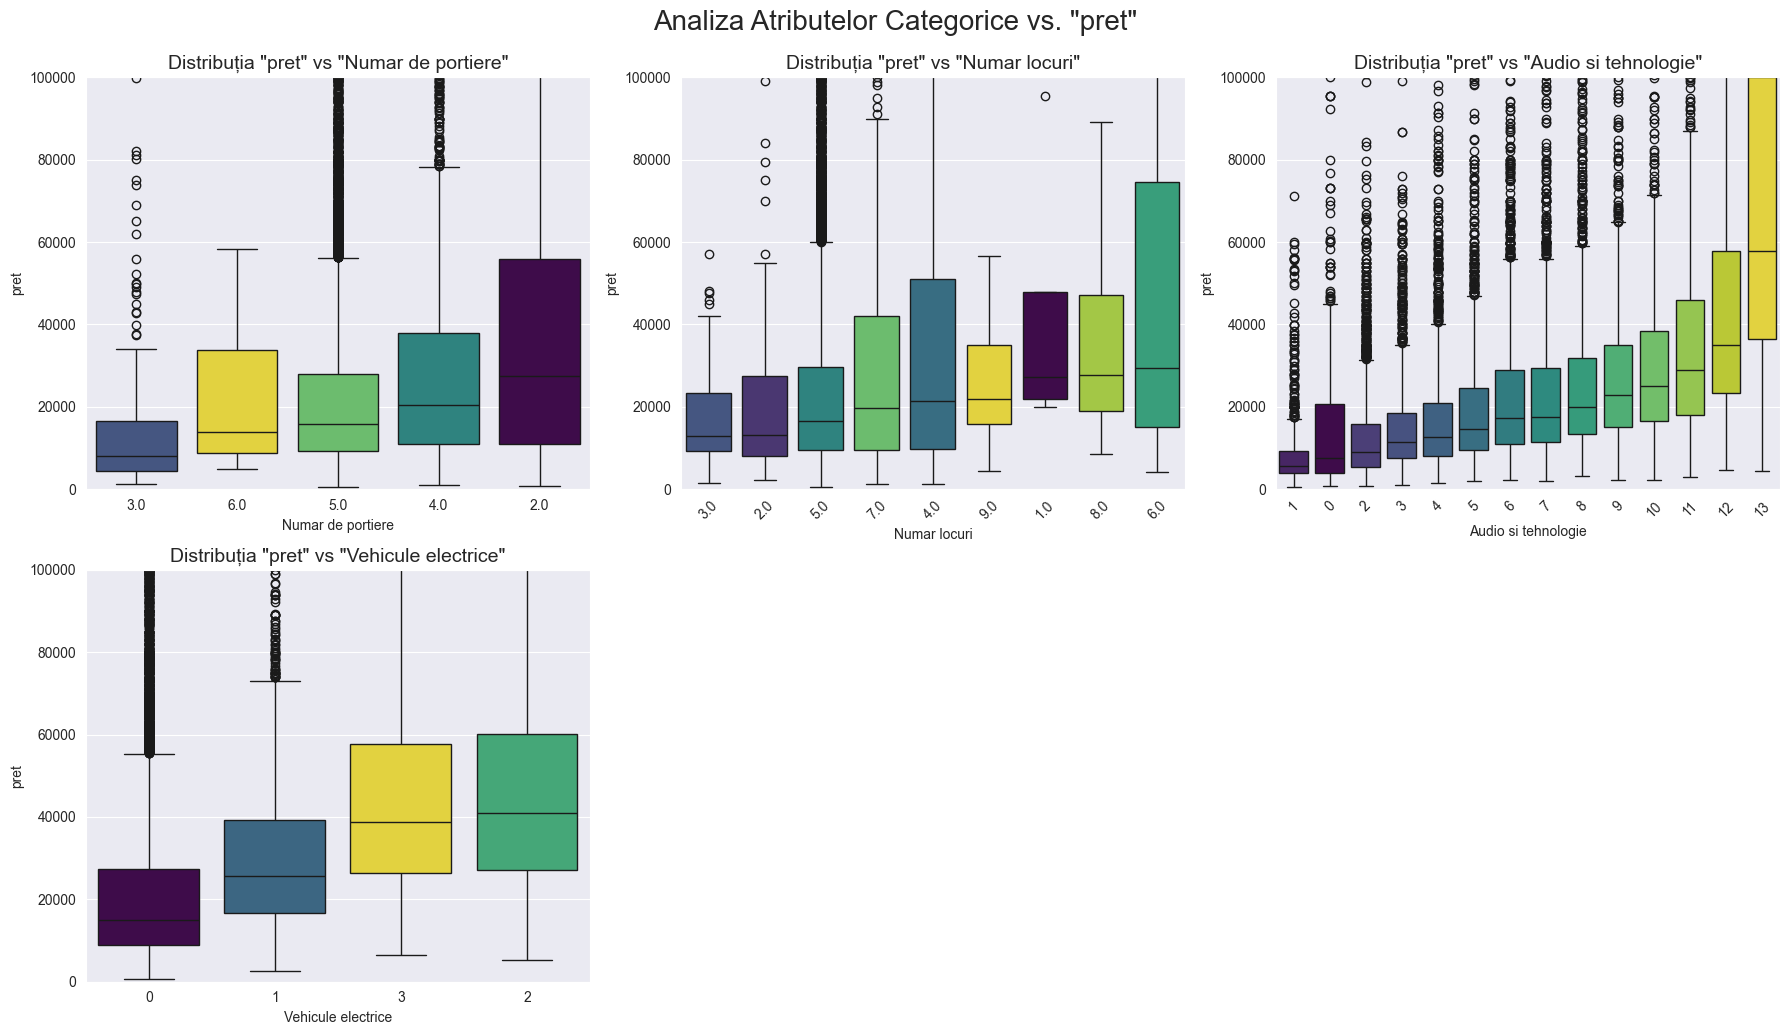

In [130]:
def plot_all_categoricals_grid(df, target_col, max_unique_values=15, y_limit=None, n_cols=3):
    categorical_cols = df.select_dtypes(include=['int64', 'float64', 'category']).columns

    cols_to_plot = []
    for col in categorical_cols:
        unique_count = df[col].nunique()
        if unique_count > 0 and unique_count <= max_unique_values:
            cols_to_plot.append(col)

    n_plots = len(cols_to_plot)
    if n_plots == 0:
        print("Nu am găsit nicio coloană de plotat conform filtrelor.")
        return

    n_rows = int(np.ceil(n_plots / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
    axes_flat = axes.flatten()

    for i, col in enumerate(cols_to_plot):
        ax = axes_flat[i]
        try:
            median_order = df.groupby(col)[target_col].median().sort_values().index
        except Exception:
            median_order = None

        sns.boxplot(
            x=col,
            y=target_col,
            data=df,
            order=median_order,
            palette="viridis",
            hue=col,
            legend=False,
            ax=ax
        )

        ax.set_title(f'Distribuția "{target_col}" vs "{col}"', fontsize=14)
        ax.set_ylabel(target_col, fontsize=10)
        ax.set_xlabel(col, fontsize=10)

        if y_limit:
            ax.set_ylim(0, y_limit)

        unique_count = df[col].nunique()
        if unique_count > 5:
            ax.tick_params(axis='x', rotation=45)

    for i in range(n_plots, len(axes_flat)):
        axes_flat[i].axis('off')

    plt.tight_layout()
    fig.suptitle(f'Analiza Atributelor Categorice vs. "{target_col}"', fontsize=20, y=1.03)
    plt.show()

plot_all_categoricals_grid(train_data, target_col='pret', max_unique_values=15, y_limit=100000, n_cols=3)

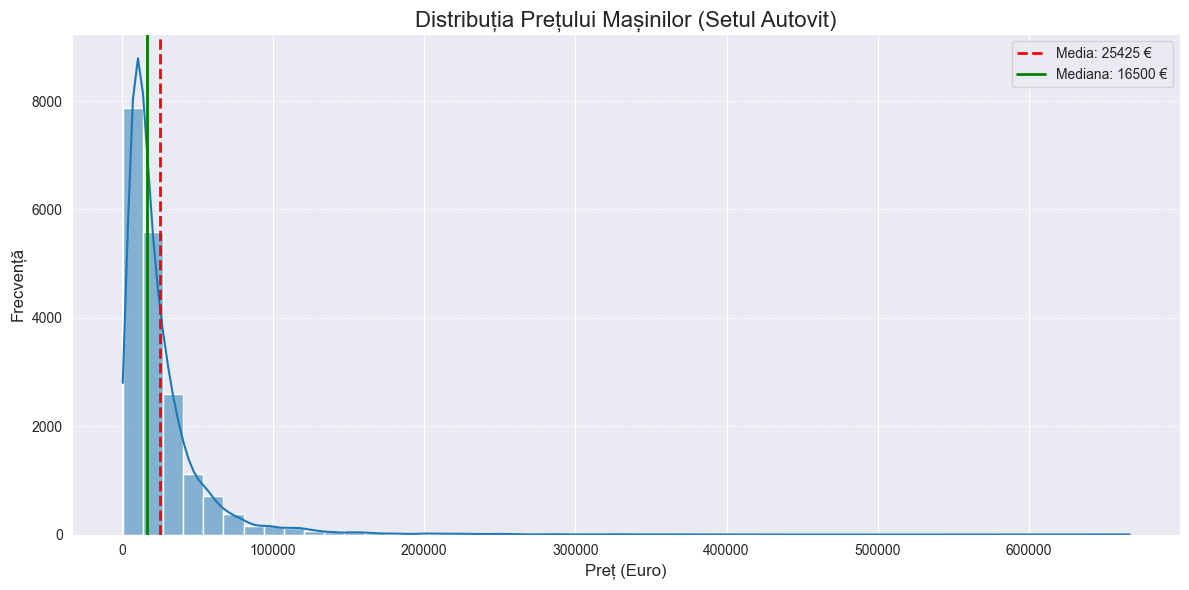

Skewness (Asimetrie) - Date Originale: 5.01


In [131]:
target_variable = train_data['pret']

plt.figure(figsize=(12, 6))
sns.histplot(target_variable, kde=True, bins=50)
plt.title('Distribuția Prețului Mașinilor (Setul Autovit)', fontsize=16)
plt.xlabel('Preț (Euro)', fontsize=12)
plt.ylabel('Frecvență', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.axvline(target_variable.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {target_variable.mean():.0f} €')
plt.axvline(target_variable.median(), color='green', linestyle='-', linewidth=2, label=f'Mediana: {target_variable.median():.0f} €')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Skewness (Asimetrie) - Date Originale: {target_variable.skew():.2f}")

- The target variable 'pret' (price) shows a right-skewed distribution, indicating that most car prices are concentrated at the lower end, with a few high-priced outliers.
- The mean price is higher than the median, further confirming the presence of high-value outliers.
- To address this skewness, a logarithmic transformation of the target variable will be applied in subsequent modeling steps.

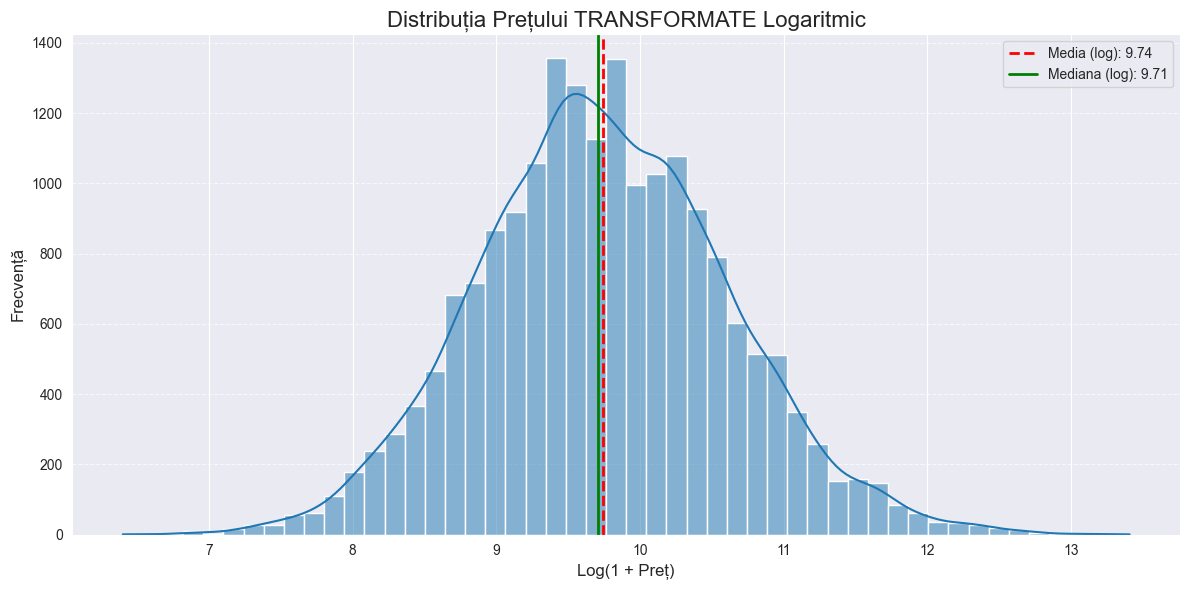

Skewness (Asimetrie) - Date Transformate: 0.13


In [132]:
target_variable_log = np.log1p(train_data['pret'])

plt.figure(figsize=(12, 6))
sns.histplot(target_variable_log, kde=True, bins=50)
plt.title('Distribuția Prețului TRANSFORMATE Logaritmic', fontsize=16)
plt.xlabel('Log(1 + Preț)', fontsize=12)
plt.ylabel('Frecvență', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Afișarea mediei și medianei datelor transformate
plt.axvline(target_variable_log.mean(), color='red', linestyle='--', linewidth=2, label=f'Media (log): {target_variable_log.mean():.2f}')
plt.axvline(target_variable_log.median(), color='green', linestyle='-', linewidth=2, label=f'Mediana (log): {target_variable_log.median():.2f}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Skewness (Asimetrie) - Date Transformate: {target_variable_log.skew():.2f}")

### 1.2.3 Correlation between Numerical Features

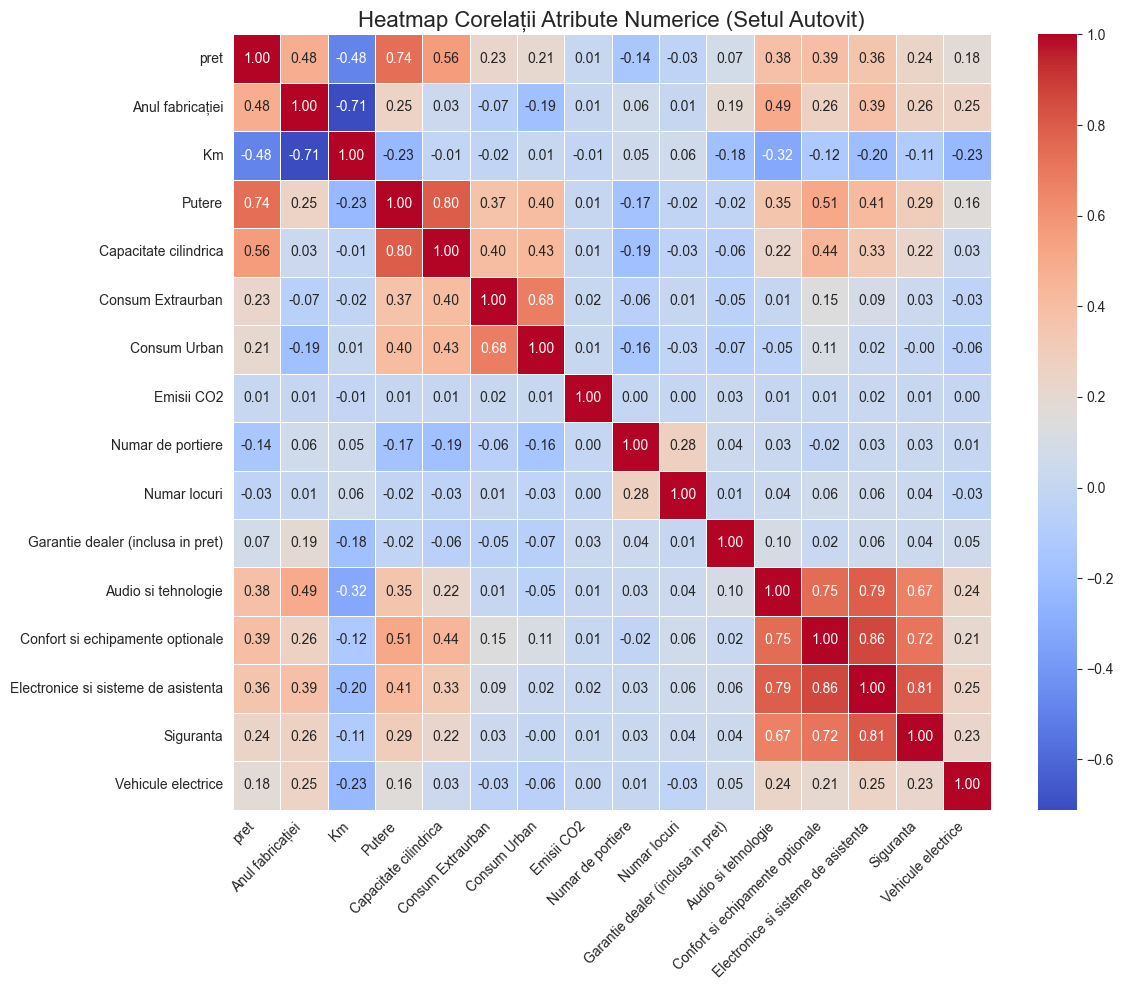

In [133]:
numerical_cols = []
for col in train_data.select_dtypes(include=['int64', 'float64']).columns:
    numerical_cols.append(col)

existing_numerical_cols = [col for col in numerical_cols if col in train_data.columns]
numerical_data = train_data[existing_numerical_cols]

corr_matrix = numerical_data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Heatmap Corelații Atribute Numerice (Setul Autovit)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


--- TOP 10 Factori care CRESC prețul ---
pret                                   0.796209
Anul fabricației                       0.747766
Putere                                 0.694436
Audio si tehnologie                    0.538874
Electronice si sisteme de asistenta    0.525144
Capacitate cilindrica                  0.520499
Confort si echipamente optionale       0.512141
Marca_Mercedes-Benz                    0.359058
Tip Caroserie_SUV                      0.347019
Siguranta                              0.346822
Name: LOG_PRET, dtype: float64

--- TOP 10 Factori care SCAD prețul ---
Marca_Opel                -0.169878
Tip Caroserie_Compacta    -0.203372
Tip Caroserie_Combi       -0.231534
Oferit de_Privat          -0.244231
Norma de poluare_Euro 4   -0.284563
Stare_Second hand         -0.302108
Norma de poluare_Euro 5   -0.313748
Transmisie_Fata           -0.418618
Cutie de viteze_Manuala   -0.606248
Km                        -0.625429
Name: LOG_PRET, dtype: float64


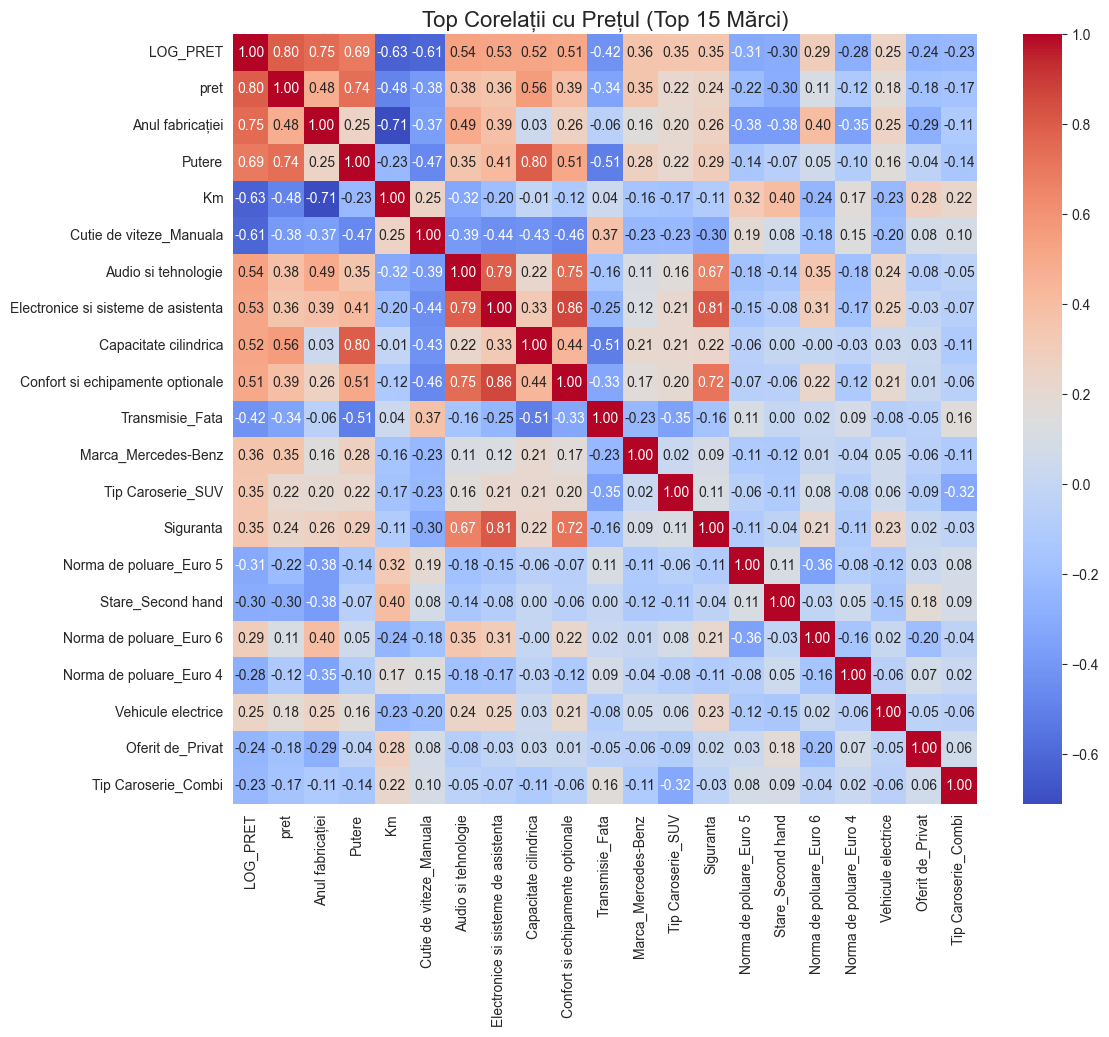

In [134]:
train_data['LOG_PRET'] = np.log1p(train_data['pret'])
all_correlations = train_data.corr()['LOG_PRET'].sort_values(ascending=False)

print("\n--- TOP 10 Factori care CRESC prețul ---")
print(all_correlations.head(11).drop('LOG_PRET'))

print("\n--- TOP 10 Factori care SCAD prețul ---")
print(all_correlations.tail(10))

# Heatmap
top_features = all_correlations.abs().sort_values(ascending=False).head(21).index
plt.figure(figsize=(12, 10))
sns.heatmap(train_data[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Top Corelații cu Prețul (Top 15 Mărci)', fontsize=16)
plt.show()

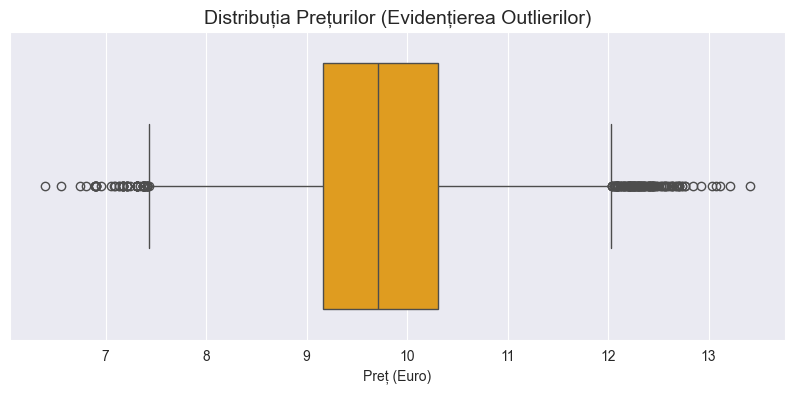


--- TOP 10 Cele mai SCUMPE mașini ---


,pret,Anul fabricației,Putere,Km,Marca_Audi,Marca_BMW,Marca_Citroën,Marca_Dacia,Marca_Ford,Marca_Hyundai,Marca_Kia,Marca_Land Rover,Marca_Mazda,Marca_Mercedes-Benz,Marca_Nissan,Marca_Opel,Marca_Peugeot,Marca_Porsche,Marca_Renault,Marca_Seat,Marca_Skoda,Marca_Toyota,Marca_Volkswagen,Marca_Volvo
329,666666.000000,2024,110.000000,500.000000,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4705,550000.000000,2022,1001.000000,2300.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2757,493850.000000,2023,571.000000,2000.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2905,474810.000000,2022,585.000000,500.000000,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3349,458150.000000,2021,571.000000,15000.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6257,410000.000000,2019,571.000000,49800.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1554,379900.000000,2019,571.000000,75000.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4788,349899.000000,2018,740.000000,12500.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2483,348908.000000,2023,550.000000,10300.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
10218,339998.000000,2023,650.000000,200.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False



--- TOP 10 Cele mai IEFTINE mașini ---


,pret,Anul fabricației,Putere,Km,Marca_Audi,Marca_BMW,Marca_Citroën,Marca_Dacia,Marca_Ford,Marca_Hyundai,Marca_Kia,Marca_Land Rover,Marca_Mazda,Marca_Mercedes-Benz,Marca_Nissan,Marca_Opel,Marca_Peugeot,Marca_Porsche,Marca_Renault,Marca_Seat,Marca_Skoda,Marca_Toyota,Marca_Volkswagen,Marca_Volvo
4297,600.000000,2005,48.000000,169000.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11455,700.000000,2007,80.000000,262411.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
8447,850.000000,2006,70.000000,256420.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
10722,900.000000,2002,103.000000,298000.000000,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
6973,990.000000,2001,60.000000,211000.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
5899,990.000000,2001,75.000000,194153.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2423,990.000000,2003,75.000000,407966.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
12854,990.000000,2004,100.000000,214053.000000,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9470,1000.000000,2007,75.000000,230000.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
4923,1000.000000,1999,116.000000,243000.000000,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [135]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=train_data['LOG_PRET'], color='orange')
plt.title('Distribuția Prețurilor (Evidențierea Outlierilor)', fontsize=14)
plt.xlabel('Preț (Euro)')
plt.xscale('linear')
plt.show()

print("\n--- TOP 10 Cele mai SCUMPE mașini ---")
cols_to_view = ['pret', 'Anul fabricației', 'Putere', 'Km']
marca_cols = [col for col in train_data.columns if 'Marca_' in col]

top_expensive = train_data.sort_values('pret', ascending=False).head(10)
display(top_expensive[cols_to_view + marca_cols].style.background_gradient(subset=['pret'], cmap='Reds'))


print("\n--- TOP 10 Cele mai IEFTINE mașini ---")
top_cheap = train_data.sort_values('pret', ascending=True).head(10)
display(top_cheap[cols_to_view + marca_cols].style.background_gradient(subset=['pret'], cmap='Blues'))

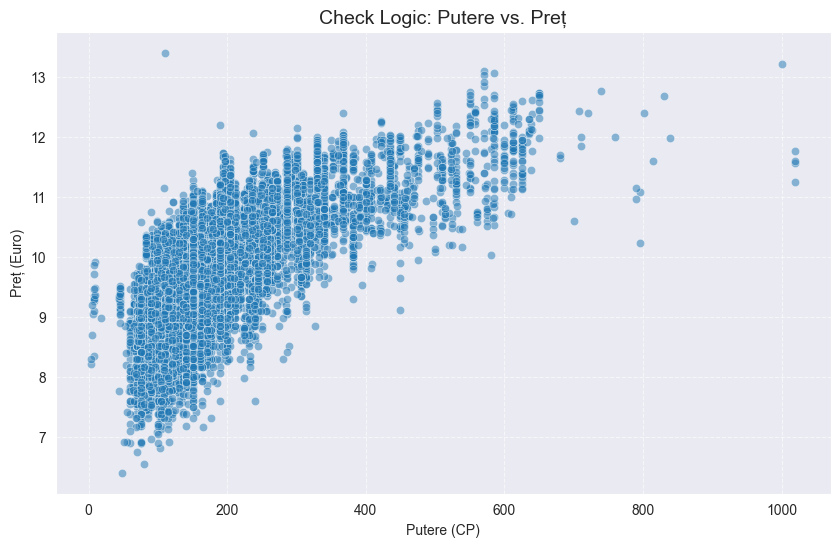

In [136]:
# 4. CHECK LOGIC: Putere vs Preț
# Verificăm dacă mașinile scumpe au și putere mare (ceea ce ar confirma că sunt valide)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_data['Putere'], y=train_data['LOG_PRET'], alpha=0.5)
plt.title('Check Logic: Putere vs. Preț', fontsize=14)
plt.xlabel('Putere (CP)')
plt.ylabel('Preț (Euro)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### 1.3 Standardisation and Normalisation

In [137]:
numeric_cols = [
    'Km', 'Putere', 'Capacitate cilindrica', 'Consum Extraurban',
    'Consum Urban', 'Emisii CO2', 'Garantie dealer (inclusa in pret)',
    'Anul fabricației', 'Numar de portiere', 'Numar locuri',
    'Audio si tehnologie', 'Confort si echipamente optionale',
    'Electronice si sisteme de asistenta', 'Siguranta'
]

scaler = StandardScaler()

train_data[numeric_cols] = scaler.fit_transform(train_data[numeric_cols])
test_data[numeric_cols] = scaler.transform(test_data[numeric_cols])

#### 1.4 Feature Selection after cleaning and normalising

In [138]:
features_to_drop = [
    'Capacitate cilindrica',  # Redundant (corelat cu Putere)
    'Consum Extraurban',      # Redundant (corelat cu Consum Urban)
    'Numar de portiere',      # Irelevant (corelație < 0.05)
    'Numar locuri'            # Irelevant (corelație < 0.05)
]

print(f"Se elimină {len(features_to_drop)} atribute: {features_to_drop}")

train_data = train_data.drop(columns=features_to_drop, errors='ignore')
test_data = test_data.drop(columns=features_to_drop, errors='ignore')

print("\n✅ Feature Selection finalizat.")
print(f"Numărul final de coloane pentru antrenare: {train_data.shape[1]}")

Se elimină 4 atribute: ['Capacitate cilindrica', 'Consum Extraurban', 'Numar de portiere', 'Numar locuri']

✅ Feature Selection finalizat.
Numărul final de coloane pentru antrenare: 110


#### 1.5 Models Training and Evaluation

In [139]:
X_train_final = train_data.drop(['pret', 'LOG_PRET'], axis=1, errors='ignore')
y_train_log = np.log1p(train_data['pret'])

X_val_final = test_data.drop(['pret', 'LOG_PRET'], axis=1, errors='ignore')
y_val_orig = test_data['pret']

# --- INIȚIALIZARE LISTĂ REZULTATE ---
final_results_list = []
print("Lista de rezultate a fost inițializată/resetată.")

Lista de rezultate a fost inițializată/resetată.


In [140]:
param_dist_linear = {
    'alpha': loguniform(1e-3, 1e3),
    'solver': ['auto', 'svd', 'cholesky', 'lsqr']
}

ridge_model = Ridge()

random_search_linear = RandomizedSearchCV(
    estimator=ridge_model,
    param_distributions=param_dist_linear,
    n_iter=20,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search_linear.fit(X_train_final, y_train_log)

print("\n--- Cei mai buni parametri găsiți pentru Ridge ---")
print(random_search_linear.best_params_)

best_linear = random_search_linear.best_estimator_

y_pred_log = best_linear.predict(X_val_final)
y_pred_euro = np.expm1(y_pred_log)

mse = mean_squared_error(y_val_orig, y_pred_euro)
mae = mean_absolute_error(y_val_orig, y_pred_euro)
r2 = r2_score(y_val_orig, y_pred_euro)

results_linear_tuned = pd.DataFrame([{
    'Model': 'Linear Regression (Ridge Tuned)',
    'Params': str(random_search_linear.best_params_),
    'MSE': mse,
    'MAE': mae,
    'R2': r2
}])

display(results_linear_tuned)

final_results_list.append({
    'Algoritm': 'Linear Regression (Ridge)',
    'Params': str(random_search_linear.best_params_),
    'MSE (Test)': f"{mse:,.0f}",
    'MAE (Test)': f"{mae:,.0f} €",
    'R2 Score': f"{r2:.4f}"
})

Fitting 3 folds for each of 20 candidates, totalling 60 fits

--- Cei mai buni parametri găsiți pentru Ridge ---
{'alpha': np.float64(98.77700294007911), 'solver': 'svd'}


,Model,Params,MSE,MAE,R2
0,Linear Regression (Ridge Tuned),"{'alpha': np.float64(98.77700294007911), 'solv...",1.564485e+08,4721.243851,0.817808


In [141]:
param_dist_svr = {
    'kernel': ['linear', 'rbf'],       # Tipurile de kernel
    'C': loguniform(1e-1, 1e2),        # Regularizare între 0.1 și 100
    'gamma': ['scale', 'auto']         # Coeficientul de kernel
}

svr = SVR()

random_search_svr = RandomizedSearchCV(
    estimator=svr,
    param_distributions=param_dist_svr,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Începe căutarea RandomizedSearch pentru SVR (poate dura câteva minute)...")
random_search_svr.fit(X_train_final, y_train_log)

print("\n--- Cei mai buni parametri găsiți pentru SVR ---")
print(random_search_svr.best_params_)

best_svr = random_search_svr.best_estimator_

y_pred_log = best_svr.predict(X_val_final)
y_pred_euro = np.expm1(y_pred_log)

mse = mean_squared_error(y_val_orig, y_pred_euro)
mae = mean_absolute_error(y_val_orig, y_pred_euro)
r2 = r2_score(y_val_orig, y_pred_euro)

results_svr = pd.DataFrame([{
    'Model': 'SVR (Tuned)',
    'Params': str(random_search_svr.best_params_),
    'MSE': mse,
    'MAE': mae,
    'R2': r2
}])

display(results_svr)
final_results_list.append({
    'Algoritm': 'SVR (Tuned)',
    'Params': str(random_search_svr.best_params_),
    'MSE (Test)': f"{mse:,.0f}",
    'MAE (Test)': f"{mae:,.0f} €",
    'R2 Score': f"{r2:.4f}"
})

Începe căutarea RandomizedSearch pentru SVR (poate dura câteva minute)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

--- Cei mai buni parametri găsiți pentru SVR ---
{'C': np.float64(31.428808908401084), 'gamma': 'auto', 'kernel': 'rbf'}


,Model,Params,MSE,MAE,R2
0,SVR (Tuned),"{'C': np.float64(31.428808908401084), 'gamma':...",1.127424e+08,3858.65669,0.868706


In [142]:
param_dist_rf = {
    'n_estimators': randint(100, 300),       # Între 100 și 300 de arbori
    'max_depth': randint(5, 20),         # Adâncimea arborelui
    'min_samples_split': randint(2, 10),     # Minim mostre pentru split
    'min_samples_leaf': randint(5, 20),       # Minim mostre într-o frunză
    'max_features': ['sqrt', 'log2', None]   # Câte atribute vede fiecare arbore
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Începe căutarea RandomizedSearch pentru Random Forest...")
random_search_rf.fit(X_train_final, y_train_log)

print("\n--- Cei mai buni parametri pentru Random Forest ---")
print(random_search_rf.best_params_)

best_rf = random_search_rf.best_estimator_

y_pred_log = best_rf.predict(X_val_final)
y_pred_euro = np.expm1(y_pred_log)

mse = mean_squared_error(y_val_orig, y_pred_euro)
mae = mean_absolute_error(y_val_orig, y_pred_euro)
r2 = r2_score(y_val_orig, y_pred_euro)

results_rf = pd.DataFrame([{
    'Model': 'Random Forest (Tuned)',
    'Params': str(random_search_rf.best_params_),
    'MSE': mse,
    'MAE': mae,
    'R2': r2
}])

display(results_rf)

final_results_list.append({
    'Algoritm': 'Random Forest (Tuned)',
    'Params': str(random_search_rf.best_params_),
    'MSE (Test)': f"{mse:,.0f}",
    'MAE (Test)': f"{mae:,.0f} €",
    'R2 Score': f"{r2:.4f}"
})

Începe căutarea RandomizedSearch pentru Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

--- Cei mai buni parametri pentru Random Forest ---
{'max_depth': 15, 'max_features': None, 'min_samples_leaf': 19, 'min_samples_split': 3, 'n_estimators': 287}


,Model,Params,MSE,MAE,R2
0,Random Forest (Tuned),"{'max_depth': 15, 'max_features': None, 'min_s...",1.327906e+08,4446.326066,0.845359


In [143]:
param_dist_gbr = {
    'n_estimators': randint(100, 300),
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # Viteza de învățare (critică pt GBR)
    'max_depth': randint(3, 8),              # Arborii sunt de obicei mai mici la Boosting
    'min_samples_split': randint(2, 10),
    'subsample': [0.8, 0.9, 1.0]             # Folosește doar o parte din date pt fiecare arbore
}

gbr = GradientBoostingRegressor(random_state=42, loss='squared_error')
random_search_gbr = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist_gbr,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Începe căutarea RandomizedSearch pentru Gradient Boosting...")
random_search_gbr.fit(X_train_final, y_train_log)

print("\n--- Cei mai buni parametri pentru Gradient Boosting ---")
print(random_search_gbr.best_params_)

best_gbr = random_search_gbr.best_estimator_

y_pred_log = best_gbr.predict(X_val_final)
y_pred_euro = np.expm1(y_pred_log)

mse = mean_squared_error(y_val_orig, y_pred_euro)
mae = mean_absolute_error(y_val_orig, y_pred_euro)
r2 = r2_score(y_val_orig, y_pred_euro)

results_gbr = pd.DataFrame([{
    'Model': 'Gradient Boosting (Squared Error)',
    'Params': str(random_search_gbr.best_params_),
    'MSE': mse,
    'MAE': mae,
    'R2': r2
}])

display(results_gbr)

final_results_list.append({
    'Algoritm': 'Gradient Boosting (Tuned)',
    'Params': str(random_search_gbr.best_params_),
    'MSE (Test)': f"{mse:,.0f}",
    'MAE (Test)': f"{mae:,.0f} €",
    'R2 Score': f"{r2:.4f}"
})

Începe căutarea RandomizedSearch pentru Gradient Boosting...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

--- Cei mai buni parametri pentru Gradient Boosting ---
{'learning_rate': 0.1, 'max_depth': 7, 'min_samples_split': 4, 'n_estimators': 234, 'subsample': 0.8}


,Model,Params,MSE,MAE,R2
0,Gradient Boosting (Squared Error),"{'learning_rate': 0.1, 'max_depth': 7, 'min_sa...",7.722853e+07,3495.192271,0.910064


Începe antrenarea modelelor de Regresie cu Cuantile...
  Antrenare Gradient Boosting pentru cuantila 0.05...
  Antrenare Gradient Boosting pentru cuantila 0.5...
  Antrenare Gradient Boosting pentru cuantila 0.95...
Antrenare finalizată.

--- Performanța Modelului Median (alpha=0.5) ---
MAE Median: 3,849 Euro
R2 Median:  0.8710

--- Analiza Intervalului de Predicție (90%) ---
Target: Intervalul ar trebui să acopere 90% din cazuri.
Realizat: Intervalul nostru acoperă 87.17% din prețurile reale.


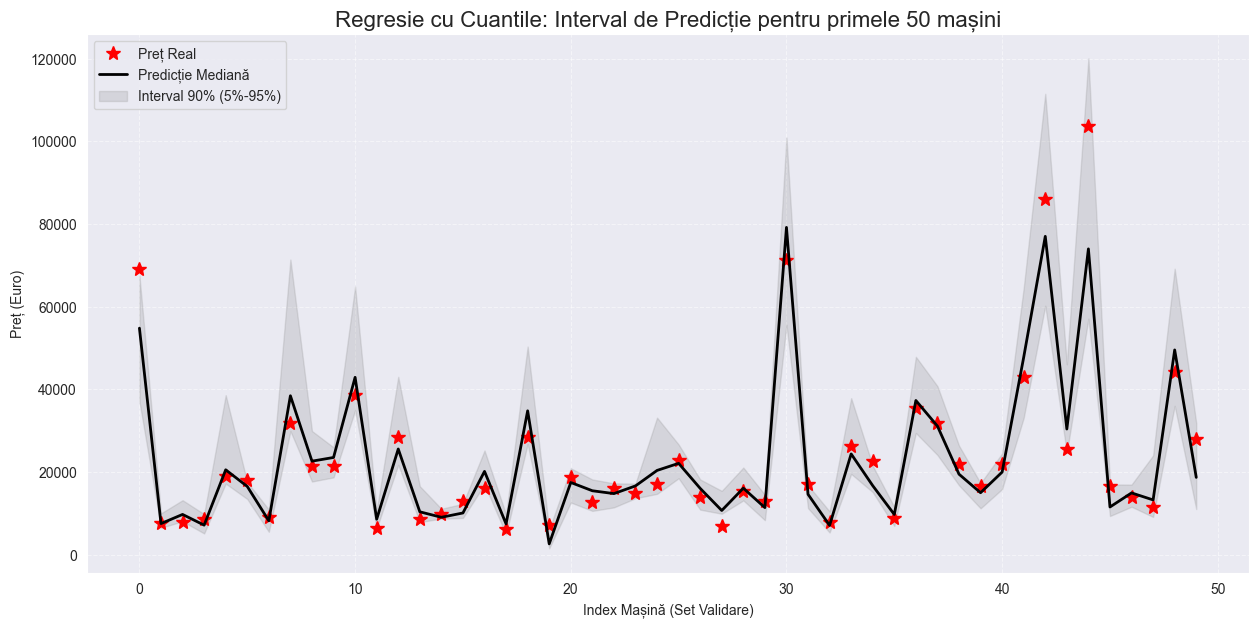

In [144]:
alphas = [0.05, 0.50, 0.95]
models_q = {}
predictions_q = {}

print("Începe antrenarea modelelor de Regresie cu Cuantile...")

# Antrenăm 3 modele separate (unul pentru fiecare cuantilă)
for alpha in alphas:
    print(f"  Antrenare Gradient Boosting pentru cuantila {alpha}...")
    gbr_quantile = GradientBoostingRegressor(
        loss='quantile',
        alpha=alpha,
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )

    gbr_quantile.fit(X_train_final, y_train_log)
    models_q[alpha] = gbr_quantile

    y_pred_log = gbr_quantile.predict(X_val_final)
    predictions_q[alpha] = np.expm1(y_pred_log)

print("Antrenare finalizată.")

y_lower = predictions_q[0.05]
y_med   = predictions_q[0.50]
y_upper = predictions_q[0.95]

mae_med = mean_absolute_error(y_val_orig, y_med)
r2_med = r2_score(y_val_orig, y_med)

print("\n--- Performanța Modelului Median (alpha=0.5) ---")
print(f"MAE Median: {mae_med:,.0f} Euro")
print(f"R2 Median:  {r2_med:.4f}")

# "Acoperirea" (Câte mașini reale au căzut în intervalul prezis?)
# Verificăm dacă prețul real este între limita de jos și cea de sus
in_interval = (y_val_orig >= y_lower) & (y_val_orig <= y_upper)
coverage = in_interval.mean() * 100

print("\n--- Analiza Intervalului de Predicție (90%) ---")
print(f"Target: Intervalul ar trebui să acopere 90% din cazuri.")
print(f"Realizat: Intervalul nostru acoperă {coverage:.2f}% din prețurile reale.")

sorted_idx = np.argsort(y_val_orig)[:50]
subset_idx = range(50)

plt.figure(figsize=(15, 7))
plt.plot(subset_idx, y_val_orig.iloc[subset_idx], 'r*', label='Preț Real', markersize=10)
plt.plot(subset_idx, y_med[subset_idx], 'k-', label='Predicție Mediană', linewidth=2)
plt.fill_between(subset_idx, y_lower[subset_idx], y_upper[subset_idx], color='gray', alpha=0.2, label='Interval 90% (5%-95%)')

plt.title('Regresie cu Cuantile: Interval de Predicție pentru primele 50 mașini', fontsize=16)
plt.xlabel('Index Mașină (Set Validare)')
plt.ylabel('Preț (Euro)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

quantile_params = {
    'loss': 'quantile',
    'n_estimators': 200,
    'max_depth': 5,
    'learning_rate': 0.1,
    'random_state': 42
}
params_str = str(quantile_params)

final_results_list.append({
    'Algoritm': 'GBR Quantile (Median)',
    'Params': params_str,
    'MSE (Test)': '-',
    'MAE (Test)': f"{mae_med:,.0f} €",
    'R2 Score': f"{r2_med:.4f}"
})

In [145]:
if 'final_results_list' in locals() and len(final_results_list) > 0:
    df_results_final = pd.DataFrame(final_results_list)

    try:
        df_results_final['sort_val'] = df_results_final['R2 Score'].astype(float)
        df_results_final = df_results_final.sort_values('sort_val', ascending=False).drop('sort_val', axis=1)
    except Exception:
        pass

    display(df_results_final.style.highlight_max(subset=['R2 Score'], color='green', axis=0))

    csv_filename = 'rezultate_finale_autovit.csv'
    df_results_final.to_csv(csv_filename, index=False)
    print(f"\n[INFO] Tabelul a fost salvat și în fișierul: '{csv_filename}'")

,Algoritm,Params,MSE (Test),MAE (Test),R2 Score
3,Gradient Boosting (Tuned),"{'learning_rate': 0.1, 'max_depth': 7, 'min_samples_split': 4, 'n_estimators': 234, 'subsample': 0.8}","77,228,534","3,495 €",0.9101
4,GBR Quantile (Median),"{'loss': 'quantile', 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'random_state': 42}",-,"3,849 €",0.8710
1,SVR (Tuned),"{'C': np.float64(31.428808908401084), 'gamma': 'auto', 'kernel': 'rbf'}","112,742,429","3,859 €",0.8687
2,Random Forest (Tuned),"{'max_depth': 15, 'max_features': None, 'min_samples_leaf': 19, 'min_samples_split': 3, 'n_estimators': 287}","132,790,612","4,446 €",0.8454
0,Linear Regression (Ridge),"{'alpha': np.float64(98.77700294007911), 'solver': 'svd'}","156,448,502","4,721 €",0.8178



[INFO] Tabelul a fost salvat și în fișierul: 'rezultate_finale_autovit.csv'
